In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from tqdm import tqdm

In [3]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
ifg_color = '#6A5ACD'
insula_color = '#D4AF37'


reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')

Using notebook 3d backend.


# Load TRF results

In [12]:
ref = 'bipolar'

tasks = ['PhonemeSequence',
         'LexicalDelay']

pts = []
for task in tasks:
    
    print(task)
    hga_path = BIDSPath(
        root=f'../results/{task}({ref})',
        datatype='mtrf',
        # suffix='m',
        extension='.csv',
        check=False,
    )
    pts.extend(hga_path.match())

HGAs = pd.concat([pd.read_csv(path) for path in pts], ignore_index=True)
HGAs.head()

PhonemeSequence
LexicalDelay


,channel,time,weight,pearsonr,feature,subject,task,description,processing,significant,label,roi,hemi,x,y,z,suffix
0,D0019_ROG13-14,-0.203125,-2.779224,-0.002101,feature_0,D0019,PhonemeSequence,Repeat,Stimulus,False,ctx_rh_G_occipital_middle,mOccG,R,41.472074,-88.150203,-3.545099,e
1,D0019_ROG13-14,-0.195312,-0.226842,-0.002101,feature_0,D0019,PhonemeSequence,Repeat,Stimulus,False,ctx_rh_G_occipital_middle,mOccG,R,41.472074,-88.150203,-3.545099,e
2,D0019_ROG13-14,-0.187500,1.036661,-0.002101,feature_0,D0019,PhonemeSequence,Repeat,Stimulus,False,ctx_rh_G_occipital_middle,mOccG,R,41.472074,-88.150203,-3.545099,e
3,D0019_ROG13-14,-0.179688,1.261365,-0.002101,feature_0,D0019,PhonemeSequence,Repeat,Stimulus,False,ctx_rh_G_occipital_middle,mOccG,R,41.472074,-88.150203,-3.545099,e
4,D0019_ROG13-14,-0.171875,0.831937,-0.002101,feature_0,D0019,PhonemeSequence,Repeat,Stimulus,False,ctx_rh_G_occipital_middle,mOccG,R,41.472074,-88.150203,-3.545099,e


In [34]:
coefs = HGAs.groupby('channel').agg({
    'pearsonr': 'mean',  
    'significant': 'any',
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'hemi': 'first',
    'subject': 'first',
    'description': 'first',
    'task': 'first'
}).reset_index()

# coefs = coefs[(coefs.significant==True)]
# remove nan
coefs = coefs.dropna(subset=['pearsonr'])
coefs.head()

,channel,pearsonr,significant,x,y,z,roi,hemi,subject,description,task
0,D0019_RIIH5-6,0.020958,False,11.886836,-94.046488,10.403848,OPC,R,D0019,Repeat,PhonemeSequence
1,D0019_RLSO7-8,0.007805,False,18.457267,-10.274114,-31.949923,PhG,R,D0019,Repeat,PhonemeSequence
2,D0019_ROG12-13,0.010229,False,31.749467,-83.233475,16.079752,OccS,R,D0019,Repeat,PhonemeSequence
3,D0019_ROG13-14,0.013512,False,41.472074,-88.150203,-3.545099,mOccG,R,D0019,Repeat,PhonemeSequence
4,D0019_ROG18-19,0.009691,False,41.531682,-78.171196,19.605156,Intersection,R,D0019,Repeat,PhonemeSequence


Dropping 1 electrodes with non-finite coords (NaN/inf)


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-03 09:50:35.832 ( 996.405s) [    7F934B23E440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x4aed5020): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-03 09:50:35.883 ( 996.456s) [    7F934B23E440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x29e3c0b0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: 

左半球: 显著 153 个电极
右半球: 显著 73 个电极


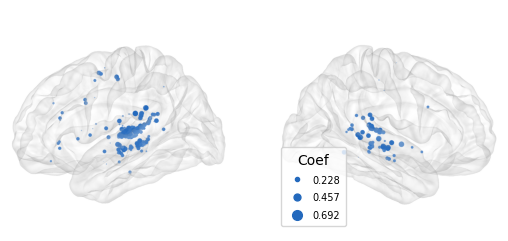

In [35]:
from IPython.display import display
from PIL import Image
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

sig_coefs = coefs[(coefs.significant == True)].copy()

cord = sig_coefs[['x', 'y', 'z']].values
coef_values = sig_coefs['pearsonr'].values
hemis = sig_coefs['hemi'].values

finite_mask = np.isfinite(cord).all(axis=1)
if not finite_mask.all():
    print(f"Dropping {int((~finite_mask).sum())} electrodes with non-finite coords (NaN/inf)")
    sig_coefs = sig_coefs.loc[finite_mask].copy()
    cord = cord[finite_mask]
    coef_values = coef_values[finite_mask]
    hemis = hemis[finite_mask]

mask_lh = hemis == 'L'
mask_rh = hemis == 'R'

cmap = blues
if len(coef_values) > 0:
    vlim = np.nanpercentile(np.abs(coef_values), 98)
    if not np.isfinite(vlim) or vlim == 0:
        mx = np.nanmax(np.abs(coef_values))
        vlim = float(mx) if np.isfinite(mx) and mx != 0 else 1.0
    norm = mcolors.TwoSlopeNorm(vmin=-vlim, vcenter=0.0, vmax=vlim)
else:
    vlim = 1.0
    norm = mcolors.TwoSlopeNorm(vmin=-vlim, vcenter=0.0, vmax=vlim)

size_min, size_max = 5, 35

def coef_to_size(c, vlim, size_min, size_max):
    if vlim == 0:
        return size_min
    normalized = np.clip(np.abs(c) / vlim, 0, 1)
    return size_min + normalized * (size_max - size_min)

lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(600*cm, 600*cm)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(600*cm, 600*cm)
)

lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_tree = cKDTree(lh_coords_pial)

rh_pial_path = f"{recon_dir}/fsaverage/surf/rh.pial"
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
rh_tree = cKDTree(rh_coords_pial)


def add_electrodes(
    brain, 
    coords_on_pial, 
    coef_vals, 
    cmap, 
    norm, 
    vlim, 
    size_min, 
    size_max
):
    for i in range(len(coords_on_pial)):
        pt = coords_on_pial[i:i+1]
        c = coef_vals[i]
        color = cmap(norm(c))[:3]
        size = coef_to_size(c, vlim, size_min, size_max)
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
            line_width=3,  # 添加黑色边框
            render_lines_as_tubes=False,
            smooth_shading=False,
            opacity=1,
        )

    
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_coef = coef_values[mask_lh]
    _, lh_indices = lh_tree.query(lh_cord)
    lh_cord_on_pial = lh_coords_pial[lh_indices]
    add_electrodes(lh_brain, lh_cord_on_pial, lh_coef, cmap, norm, vlim, size_min, size_max)

if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_coef = coef_values[mask_rh]
    _, rh_indices = rh_tree.query(rh_cord)
    rh_cord_on_pial = rh_coords_pial[rh_indices]
    add_electrodes(rh_brain, rh_cord_on_pial, rh_coef, cmap, norm, vlim, size_min, size_max)

print(f"左半球: 显著 {int(mask_lh.sum())} 个电极")
print(f"右半球: 显著 {int(mask_rh.sum())} 个电极")

for brain in (lh_brain, rh_brain):
    brain.show_view(view="lateral", distance=350)
    brain._renderer.plotter.window_size = [1400, 1400]

fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))
axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")

from matplotlib.lines import Line2D
legend_levels = np.array([0.33, 0.66, 1.0]) * vlim
legend_sizes = [coef_to_size(v, vlim, size_min, size_max) for v in legend_levels]
legend_handles = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor=blue, markeredgecolor=blue,
           markersize=s*0.2, label=f"{v:.3g}")
    for v, s in zip(legend_levels, legend_sizes)
]
axes[1].legend(
    handles=legend_handles,
    title="Coef",
    loc="lower left",
    frameon=True,
    borderpad=0.6,
    labelspacing=0.8,
    handletextpad=0.6,
    fontsize=7,
)

lh_brain.close()
rh_brain.close()

# encode acoustic 
# plt.tight_layout()
plt.savefig('../img/misc/encode_acoustic_whole_brain.svg')
plt.show()

VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-03 09:50:43.590 (1004.162s) [    7F934B23E440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x210eab60): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-03 09:50:43.647 (1004.220s) [    7F934B23E440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x232b1b00): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: 

左半球: 显著 9 个电极
右半球: 显著 0 个电极


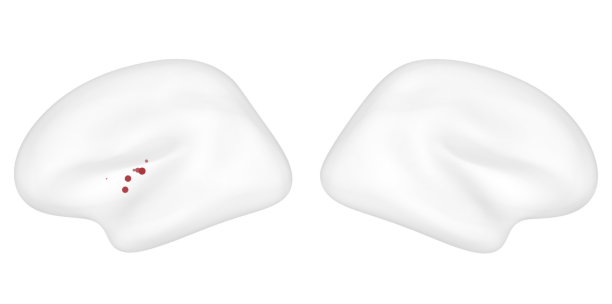

In [36]:
from IPython.display import display
from PIL import Image
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

sig_coefs = coefs[(coefs.significant == True) & (coefs.roi == 'INS')].copy()

cord = sig_coefs[['x', 'y', 'z']].values
coef_values = sig_coefs['pearsonr'].values
hemis = sig_coefs['hemi'].values

mask_lh = hemis == 'L'
mask_rh = hemis == 'R'

cmap = reds
if len(coef_values) > 0:
    vlim = np.nanpercentile(np.abs(coef_values), 98)
    if not np.isfinite(vlim) or vlim == 0:
        mx = np.nanmax(np.abs(coef_values))
        vlim = float(mx) if np.isfinite(mx) and mx != 0 else 1.0
    norm = mcolors.TwoSlopeNorm(vmin=-vlim, vcenter=0.0, vmax=vlim)
else:
    vlim = 1.0
    norm = mcolors.TwoSlopeNorm(vmin=-vlim, vcenter=0.0, vmax=vlim)

size_min, size_max = 5, 35

def coef_to_size(c, vlim, size_min, size_max):
    if vlim == 0:
        return size_min
    normalized = np.clip(np.abs(c) / vlim, 0, 1)
    return size_min + normalized * (size_max - size_min)

lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="inflated",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(600*cm, 600*cm)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="inflated",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(600*cm, 600*cm)
)

lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_infl_path = f"{recon_dir}/fsaverage/surf/lh.inflated"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_coords_infl, _ = mne.read_surface(lh_infl_path)
lh_tree = cKDTree(lh_coords_pial)

rh_pial_path = f"{recon_dir}/fsaverage/surf/rh.pial"
rh_infl_path = f"{recon_dir}/fsaverage/surf/rh.inflated"
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
rh_coords_infl, _ = mne.read_surface(rh_infl_path)
rh_tree = cKDTree(rh_coords_pial)


def add_electrodes(brain, coords_on_infl, coef_vals, cmap, norm, vlim, size_min, size_max):
    for i in range(len(coords_on_infl)):
        pt = coords_on_infl[i:i+1]
        c = coef_vals[i]
        color = cmap(norm(c))[:3]
        size = coef_to_size(c, vlim, size_min, size_max)
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=1,
        )


if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_coef = coef_values[mask_lh]
    _, lh_indices = lh_tree.query(lh_cord)
    lh_cord_on_infl = lh_coords_infl[lh_indices]
    add_electrodes(lh_brain, lh_cord_on_infl, lh_coef, cmap, norm, vlim, size_min, size_max)

if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_coef = coef_values[mask_rh]
    _, rh_indices = rh_tree.query(rh_cord)
    rh_cord_on_infl = rh_coords_infl[rh_indices]
    add_electrodes(rh_brain, rh_cord_on_infl, rh_coef, cmap, norm, vlim, size_min, size_max)

print(f"左半球: 显著 {int(mask_lh.sum())} 个电极")
print(f"右半球: 显著 {int(mask_rh.sum())} 个电极")

for brain in (lh_brain, rh_brain):
    brain.show_view(view="lateral", distance=400)
    brain._renderer.plotter.window_size = [1400, 1400]

fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))
axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")

lh_brain.close()
rh_brain.close()

plt.tight_layout()
plt.show()

In [37]:
from IPython.display import display
from PIL import Image
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors
import seaborn as sns

insula_rois = {'INS', 'Insula', 'AIC', 'PIC'}
insula_mask = coefs['roi'].isin(insula_rois)

coefs_ins_sig = coefs[(coefs.significant == True) & insula_mask].copy()
coefs_ins_nonsig = coefs[(coefs.significant == False) & insula_mask].copy()
coefs_nonins_sig = coefs[(coefs.significant == True) & (~insula_mask)].copy()

coef_values_for_norm = pd.concat([
    coefs_ins_sig['pearsonr'],
    coefs_nonins_sig['pearsonr'],
], ignore_index=True).to_numpy()

vlim = np.nanpercentile(np.abs(coef_values_for_norm), 98)
if not np.isfinite(vlim) or vlim == 0:
    mx = np.nanmax(np.abs(coef_values_for_norm))
    vlim = float(mx) if np.isfinite(mx) and mx != 0 else 1.0

norm = mcolors.Normalize(vmin=-vlim, vmax=vlim)

cmap_ins_sig = reds
cmap_nonins_sig = sns.light_palette('gray', as_cmap=True)

size_min, size_max = 10, 35
size_nonsig_ins = 4


def coef_to_size(c, vlim, size_min, size_max):
    if vlim == 0:
        return size_min
    normalized = np.clip(np.abs(c) / vlim, 0, 1)
    return size_min + normalized * (size_max - size_min)


lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="inflated",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(600*cm, 600*cm)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="inflated",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(600*cm, 600*cm)
)

# Add insula boundaries
insula_patterns = [
    'G_insular_short',
    'G_Ins_lg_and_S_cent_ins',
    'S_circular_insula_ant',
    'S_circular_insula_inf',
    'S_circular_insula_sup',
]
labels = mne.read_labels_from_annot(
    subject='fsaverage',
    parc='aparc.a2009s',
    hemi='both',
    subjects_dir=recon_dir,
)
for lab in labels:
    if any(p in lab.name for p in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=True, color='black', alpha=1.0)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=True, color='black', alpha=1.0)


lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_infl_path = f"{recon_dir}/fsaverage/surf/lh.inflated"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_coords_infl, _ = mne.read_surface(lh_infl_path)
lh_tree = cKDTree(lh_coords_pial)

rh_pial_path = f"{recon_dir}/fsaverage/surf/rh.pial"
rh_infl_path = f"{recon_dir}/fsaverage/surf/rh.inflated"
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
rh_coords_infl, _ = mne.read_surface(rh_infl_path)
rh_tree = cKDTree(rh_coords_pial)


def add_electrodes_scaled(brain, coords_on_infl, coef_vals, cmap, norm, vlim, size_min, size_max):
    for i in range(len(coords_on_infl)):
        pt = coords_on_infl[i:i+1]
        c = coef_vals[i]
        color = cmap(norm(c))[:3]
        size = coef_to_size(c, vlim, size_min, size_max)
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=1,
        )


def add_electrodes_fixed(brain, coords_on_infl, color, point_size):
    for i in range(len(coords_on_infl)):
        pt = coords_on_infl[i:i+1]
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=point_size,
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=1,
        )


def project_to_infl(df, hemi, tree, coords_infl):
    if len(df) == 0:
        return np.empty((0, 3)), np.array([])
    sub = df[df.hemi == hemi]
    if len(sub) == 0:
        return np.empty((0, 3)), np.array([])
    cord = sub[['x', 'y', 'z']].to_numpy()
    coef_vals = sub['pearsonr'].to_numpy()
    _, indices = tree.query(cord)
    cord_on_infl = coords_infl[indices]
    return cord_on_infl, coef_vals


# Draw order: non-sig insula (black) -> sig non-insula (gray) -> sig insula (red)
for hemi, brain, tree, coords_infl in [
    ('L', lh_brain, lh_tree, lh_coords_infl),
    ('R', rh_brain, rh_tree, rh_coords_infl),
]:
    cord_on_infl, _ = project_to_infl(coefs_ins_nonsig, hemi, tree, coords_infl)
    if len(cord_on_infl) > 0:
        add_electrodes_fixed(brain, cord_on_infl, color='black', point_size=size_nonsig_ins)

    cord_on_infl, coef_vals = project_to_infl(coefs_nonins_sig, hemi, tree, coords_infl)
    if len(cord_on_infl) > 0:
        add_electrodes_scaled(brain, cord_on_infl, coef_vals, cmap_nonins_sig, norm, vlim, size_min, size_max)

    cord_on_infl, coef_vals = project_to_infl(coefs_ins_sig, hemi, tree, coords_infl)
    if len(cord_on_infl) > 0:
        add_electrodes_scaled(brain, cord_on_infl, coef_vals, cmap_ins_sig, norm, vlim, size_min, size_max)


print(f"INS 显著: {len(coefs_ins_sig)}")
print(f"INS 非显著: {len(coefs_ins_nonsig)}")
print(f"非 INS 显著: {len(coefs_nonins_sig)}")

for brain in (lh_brain, rh_brain):
    brain.show_view(view="lateral", distance=400)
    brain._renderer.plotter.window_size = [1400, 1400]

fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))
axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")

lh_brain.close()
rh_brain.close()

plt.tight_layout()
plt.show()

VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-03 09:50:48.303 (1008.876s) [    7F934B23E440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x29e38b70): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-03 09:50:48.360 (1008.933s) [    7F934B23E440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x23351ff0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: 

Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


ValueError: 'x' must be finite, check for nan or inf values

VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-03 09:51:10.166 (1030.739s) [    7F934B23E440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x16c57bd0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-03 09:51:10.220 (1030.793s) [    7F934B23E440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x276191e0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: 

Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot
INS 显著: 9
INS 非显著: 94


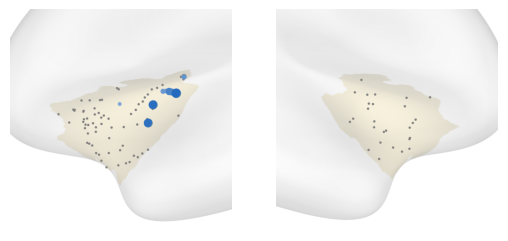

In [38]:
from IPython.display import display
from PIL import Image
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

insula_rois = {'INS', 'Insula', 'AIC', 'PIC'}
insula_mask = coefs['roi'].isin(insula_rois)

coefs_ins_sig = coefs[(coefs.significant == True) & insula_mask].copy()
# coefs_ins_sig = coefs[insula_mask].copy()
coefs_ins_nonsig = coefs[(coefs.significant == False) & insula_mask].copy()

if len(coefs_ins_sig) > 0:
    coef_values_for_norm = coefs_ins_sig['pearsonr'].to_numpy()
    vlim = np.nanpercentile(np.abs(coef_values_for_norm), 95)
    if not np.isfinite(vlim) or vlim == 0:
        mx = np.nanmax(np.abs(coef_values_for_norm))
        vlim = float(mx) if np.isfinite(mx) and mx != 0 else 1.0
else:
    vlim = 1.0

norm = mcolors.Normalize(vmin=-vlim, vmax=vlim)
cmap_ins_sig = blues
size_min, size_max = 20, 60
size_nonsig_ins = 15


def coef_to_size(c, vlim, size_min, size_max):
    if vlim == 0:
        return size_min
    normalized = np.clip(np.abs(c) / vlim, 0, 1)
    return size_min + normalized * (size_max - size_min)


lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="inflated",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(600*cm, 600*cm)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="inflated",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(600*cm, 600*cm)
)

insula_patterns = [
    'G_insular_short',
    'G_Ins_lg_and_S_cent_ins',
    'S_circular_insula_ant',
    'S_circular_insula_inf',
    'S_circular_insula_sup',
]

labels = mne.read_labels_from_annot(
    subject='fsaverage',
    parc='aparc.a2009s',
    hemi='both',
    subjects_dir=recon_dir,
)

lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_infl_path = f"{recon_dir}/fsaverage/surf/lh.inflated"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_coords_infl, _ = mne.read_surface(lh_infl_path)
lh_tree = cKDTree(lh_coords_pial)

rh_pial_path = f"{recon_dir}/fsaverage/surf/rh.pial"
rh_infl_path = f"{recon_dir}/fsaverage/surf/rh.inflated"
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
rh_coords_infl, _ = mne.read_surface(rh_infl_path)
rh_tree = cKDTree(rh_coords_pial)


def get_roi_center(labels, roi_patterns, hemi):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in roi_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        if hemi == 'lh':
            coords = lh_coords_infl[vertices]
        else:
            coords = rh_coords_infl[vertices]
        return coords.mean(axis=0)
    return None


lh_insula_center = get_roi_center(labels, insula_patterns, 'lh')
rh_insula_center = get_roi_center(labels, insula_patterns, 'rh')

for lab in labels:
    if any(p in lab.name for p in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.4)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.4)


def add_electrodes_scaled(brain, coords_on_infl, coef_vals, cmap, norm, vlim, size_min, size_max):
    for i in range(len(coords_on_infl)):
        pt = coords_on_infl[i:i+1]
        c = coef_vals[i]
        color = cmap(norm(c))[:3]
        size = coef_to_size(c, vlim, size_min, size_max)
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=1,
        )


def add_electrodes_fixed(brain, coords_on_infl, color, point_size):
    for i in range(len(coords_on_infl)):
        pt = coords_on_infl[i:i+1]
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=point_size,
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=1,
        )


def project_to_infl(df, hemi, tree, coords_infl):
    if len(df) == 0:
        return np.empty((0, 3)), np.array([])
    sub = df[df.hemi == hemi]
    if len(sub) == 0:
        return np.empty((0, 3)), np.array([])
    cord = sub[['x', 'y', 'z']].to_numpy()
    coef_vals = sub['pearsonr'].to_numpy()
    _, indices = tree.query(cord)
    cord_on_infl = coords_infl[indices]
    return cord_on_infl, coef_vals


for hemi, brain, tree, coords_infl, center in [
    ('L', lh_brain, lh_tree, lh_coords_infl, lh_insula_center),
    ('R', rh_brain, rh_tree, rh_coords_infl, rh_insula_center),
]:
    cord_on_infl, _ = project_to_infl(coefs_ins_nonsig, hemi, tree, coords_infl)
    if len(cord_on_infl) > 0:
        add_electrodes_fixed(brain, cord_on_infl, color='grey', point_size=size_nonsig_ins)

    cord_on_infl, coef_vals = project_to_infl(coefs_ins_sig, hemi, tree, coords_infl)
    if len(cord_on_infl) > 0:
        add_electrodes_scaled(brain, cord_on_infl, coef_vals, cmap_ins_sig, norm, vlim, size_min, size_max)

    if center is not None:
        brain.show_view(
            azimuth=180 if hemi == 'L' else 0,
            elevation=90,
            distance=200,
            focalpoint=center,
        )
    else:
        brain.show_view(view="lateral", distance=150)

    brain._renderer.plotter.window_size = [1400, 1400]


print(f"INS 显著: {len(coefs_ins_sig)}")
print(f"INS 非显著: {len(coefs_ins_nonsig)}")

fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))
axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")

lh_brain.close()
rh_brain.close()

plt.savefig('../img/fig2/fig2_acoustic_encode_local.svg', dpi=300, bbox_inches='tight')
plt.show()